# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [3]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
df_genes = pd.read_csv("listex4.csv", index_col="Unnamed: 0")
df_genes.head()

,num_Caracteres,freq_num_caracteres,Iniciais,Count_A,tem_hu
PPARG,5,3,"['P', 'P']",1,False
ADRB2,5,3,"['A', 'D']",1,False
TCF7L2,6,2,"['T', 'C']",0,False
FABP2,5,3,"['F', 'A']",1,False
NOTCH2,6,2,"['N', 'O']",0,False


In [6]:
df_genes['id_entrez'] = [
    "NM_001354666.3",
    "NM_000024.6",
    "NM_001367943.1",
    "NM_000134.4",
    "NM_024408.4",
]

df_genes['id_protein'] = [
    'NP_001341595',
    "NP_000015.2",
    "NP_001354872.1",
    "NP_000125.2",
    "NP_077719.2",
]
df_genes

,num_Caracteres,freq_num_caracteres,Iniciais,Count_A,tem_hu,id_entrez,id_protein
PPARG,5,3,"['P', 'P']",1,False,NM_001354666.3,NP_001341595
ADRB2,5,3,"['A', 'D']",1,False,NM_000024.6,NP_000015.2
TCF7L2,6,2,"['T', 'C']",0,False,NM_001367943.1,NP_001354872.1
FABP2,5,3,"['F', 'A']",1,False,NM_000134.4,NP_000125.2
NOTCH2,6,2,"['N', 'O']",0,False,NM_024408.4,NP_077719.2


In [15]:
import os
print(os.getcwd())

c:\Users\amand\OneDrive\Desktop\Alessandra\Aula-Phyton\Exercícios


In [21]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "alessandra.conti@fiocruz.br"

    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"./data/{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None
print(df_genes.columns)
import os

caminho = "./data"

if os.path.exists(caminho):
    print("A pasta existe")
else:
    print("A pasta NÃO existe")

Index(['num_Caracteres', 'freq_num_caracteres', 'Iniciais', 'Count_A',
       'tem_hu', 'id_entrez', 'id_protein'],
      dtype='object')
A pasta existe


In [19]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index 
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)  # Para evitar sobrecarga no servidor do NCBI


        num_Caracteres  freq_num_caracteres    Iniciais  Count_A  tem_hu  \
PPARG                5                    3  ['P', 'P']        1   False   
ADRB2                5                    3  ['A', 'D']        1   False   
TCF7L2               6                    2  ['T', 'C']        0   False   
FABP2                5                    3  ['F', 'A']        1   False   
NOTCH2               6                    2  ['N', 'O']        0   False   

             id_entrez      id_protein  
PPARG   NM_001354666.3    NP_001341595  
ADRB2      NM_000024.6     NP_000015.2  
TCF7L2  NM_001367943.1  NP_001354872.1  
FABP2      NM_000134.4     NP_000125.2  
NOTCH2     NM_024408.4     NP_077719.2  
        num_Caracteres  freq_num_caracteres    Iniciais  Count_A  tem_hu  \
PPARG                5                    3  ['P', 'P']        1   False   
ADRB2                5                    3  ['A', 'D']        1   False   
TCF7L2               6                    2  ['T', 'C']        0   Fa

In [20]:
print(df_genes.head())

        num_Caracteres  freq_num_caracteres    Iniciais  Count_A  tem_hu  \
PPARG                5                    3  ['P', 'P']        1   False   
ADRB2                5                    3  ['A', 'D']        1   False   
TCF7L2               6                    2  ['T', 'C']        0   False   
FABP2                5                    3  ['F', 'A']        1   False   
NOTCH2               6                    2  ['N', 'O']        0   False   

             id_entrez      id_protein  
PPARG   NM_001354666.3    NP_001341595  
ADRB2      NM_000024.6     NP_000015.2  
TCF7L2  NM_001367943.1  NP_001354872.1  
FABP2      NM_000134.4     NP_000125.2  
NOTCH2     NM_024408.4     NP_077719.2  


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [65]:
from Bio import SeqIO
import pandas as pd
from pathlib import Path
pasta = Path("./data")
#sendo a=alanina, c=cisteína, d=Acido Aspárico, e=ácidoglutámico, g=glicina, h=histidina, i=isoleucina, k=lisina, l=Leucina, m=metionina, n=aspargina, p=prolina, q=Glutamina, r=aspargina, s=Serina, t=treonina, v=valina, w=triptofano, y=Tirosina
aminoacidos = list("ACDEFGHIKLMNPQRSTVWY")
dados = []
for gene, row in df_genes.iterrows():
    
    id_prot = row["id_protein"]

    arquivo = pasta / f"{id_prot}.fasta"
   
    if not arquivo.exists():
        print(f"Arquivo não encontrado: {arquivo}")
        continue
    
    record = next(SeqIO.parse(arquivo, "fasta"))
    seq = str(record.seq)
    
    contagem = {aa: seq.count(aa) for aa in aminoacidos}
    
    contagem["gene"] = gene
    dados.append(contagem)
df_amino = pd.DataFrame(dados).set_index("gene")
print(df_amino)
df_amino.to_csv("df_amino.csv")

          A    C    D    E   F    G   H   I   K    L   M    N    P    Q   R  \
gene                                                                          
PPARG    26   10   32   32  26   19  14  33  39   50  15   15   23   23  19   
ADRB2    25   13   16   19  25   28  11  31  16   39  10   22   12   19  17   
TCF7L2   42    9   26   35  11   35  28  19  40   60  11   20   79   34  28   
FABP2     5    0    8   13   8   10   1   7  14   10   3   11    0    2   7   
NOTCH2  171  243  152  129  59  219  76  79  72  171  47  143  181  118  92   

          S    T    V   W   Y  
gene                           
PPARG    34   22   24   1  18  
ADRB2    29   23   36   8  14  
TCF7L2   69   29   22   5  17  
FABP2     5   11   11   2   4  
NOTCH2  181  135  119  19  65  


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [25]:
print(df_amino["V"])
gene_max = df_amino["V"].idxmax()
valor_max = df_amino["V"].max()

print(f"Gene com maior número de valina: {gene_max}")
print(f"Número de valinas no gene: {valor_max}")

gene
PPARG      24
ADRB2      36
TCF7L2     22
FABP2      11
NOTCH2    119
Name: V, dtype: int64
Gene com maior número de valina: NOTCH2
Número de valinas no gene: 119


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [32]:
Serina = df_amino["S"]
print(Serina)

media = Serina.mean()
mediana = Serina.median()
moda = Serina.mode()
#Como todos os valores só aparecem uma vez, todos são moda

print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda.values)

gene
PPARG      34
ADRB2      29
TCF7L2     69
FABP2       5
NOTCH2    181
Name: S, dtype: int64
Média: 63.6
Mediana: 34.0
Moda: [  5  29  34  69 181]


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

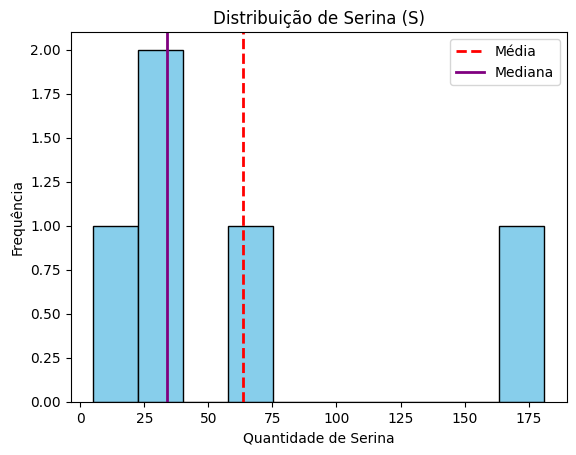

In [41]:
plt.hist(Serina, color="skyblue", edgecolor="black")

plt.axvline(Serina.mean(), color="red", linewidth=2, linestyle="--", label="Média")
plt.axvline(Serina.median(), color="purple", linewidth=2, linestyle="-", label="Mediana")

plt.title("Distribuição de Serina (S)")
plt.xlabel("Quantidade de Serina")
plt.ylabel("Frequência")

plt.legend()
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [ ]:
def hist_aminoacido(df, aminoacido):

    if aminoacido not in df.columns:
        print("Esse aa não existe!")
        return
    
    dados = df[aminoacido]
    
    plt.hist(dados, color="skyblue", edgecolor="black")
    plt.xlim(0, 80)
    plt.ylim(0, 4)
    
    # média e mediana
    plt.axvline(dados.mean(), color="red", linewidth=2, linestyle="--", label="Média")
    plt.axvline(dados.median(), color="purple", linewidth=2, linestyle="-", label="Mediana")
    
    plt.title(f"Distribuição de {aminoacido}")
    plt.xlabel("Quantidade")
    plt.ylabel("Frequência")
    
    plt.legend()
    plt.show()

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

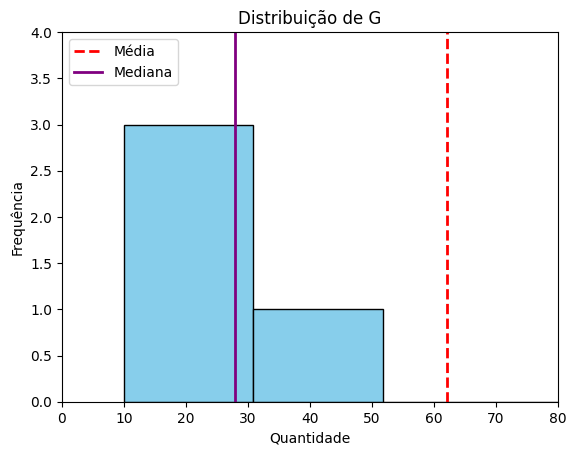

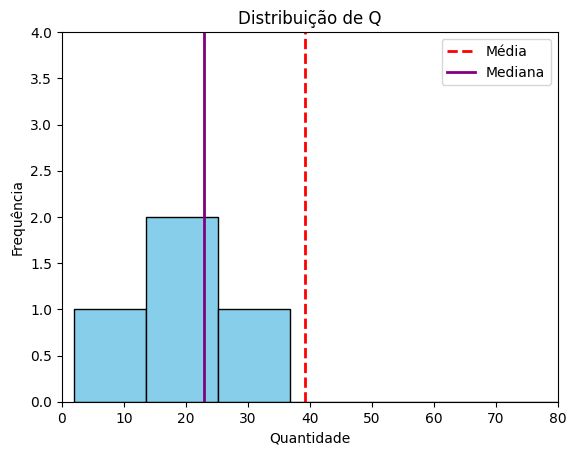

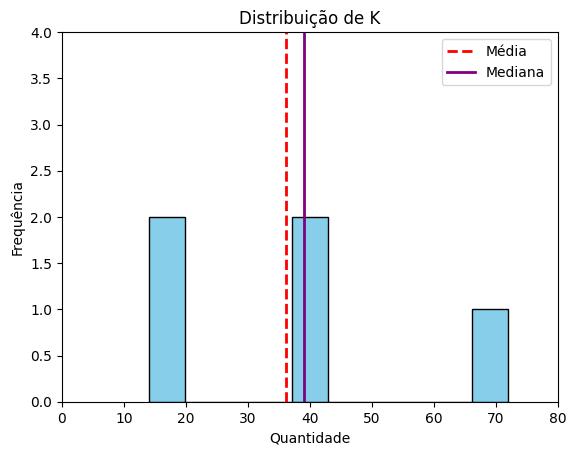

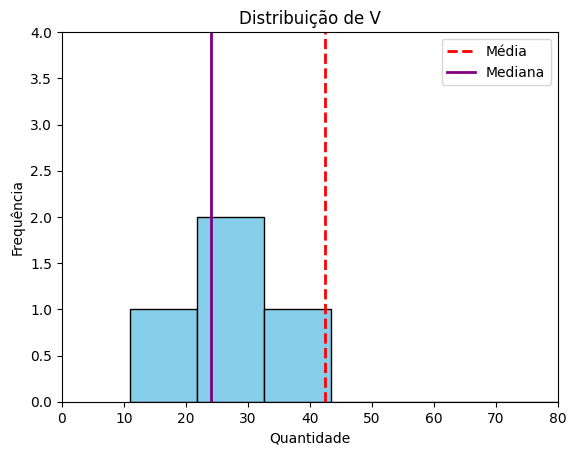

In [ ]:
hist_aminoacido(df_amino, "G") #Glicina
hist_aminoacido(df_amino, "Q") #Glutamina
hist_aminoacido(df_amino, "K") #Lisina
hist_aminoacido(df_amino, "V") #Valina
#Pelo gráfico podemos dizer que a menor diferença é entre a média e a mediana da Lisina mas...


In [52]:
def diferenca_media_mediana(df, aminoacido):
    
    if aminoacido not in df.columns:
        print("Sério que você não consegue nem lembrar as letras de cada aa??")
        return
    
    dados = df[aminoacido]
    
    media = dados.mean()
    mediana = dados.median()
    
    diferenca = abs(media - mediana)
    
    return media, mediana, diferenca


In [53]:
media, mediana, diff = diferenca_media_mediana(df_amino, "G")

print("Média:", media)
print("Mediana:", mediana)
print("Diferença:", diff)

Média: 62.2
Mediana: 28.0
Diferença: 34.2


In [54]:
media, mediana, diff = diferenca_media_mediana(df_amino, "Q")

print("Média:", media)
print("Mediana:", mediana)
print("Diferença:", diff)

Média: 39.2
Mediana: 23.0
Diferença: 16.200000000000003


In [55]:
media, mediana, diff = diferenca_media_mediana(df_amino, "K")

print("Média:", media)
print("Mediana:", mediana)
print("Diferença:", diff)

Média: 36.2
Mediana: 39.0
Diferença: 2.799999999999997


In [56]:
media, mediana, diff = diferenca_media_mediana(df_amino, "V")

print("Média:", media)
print("Mediana:", mediana)
print("Diferença:", diff)

Média: 42.4
Mediana: 24.0
Diferença: 18.4


R: A menor diferença é entre a média e a mediana da Lisina!

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [61]:
cisteina_3primeirosgenes = df_amino.loc[["PPARG", "ADRB2", "TCF7L2"], "C"]
print(cisteina_3primeirosgenes)
media = cisteina_3primeirosgenes.mean()
mediana = cisteina_3primeirosgenes.median()
moda = cisteina_3primeirosgenes.mode()
#Como todos os valores só aparecem uma vez, todos são moda

print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda.values)

gene
PPARG     10
ADRB2     13
TCF7L2     9
Name: C, dtype: int64
Média: 10.666666666666666
Mediana: 10.0
Moda: [ 9 10 13]


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [63]:
media_por_gene = df_amino.mean(axis=1)
print(media_por_gene)
gene_maior = media_por_gene.idxmax()
print("Gene com maior média de aa:", gene_maior)

gene
PPARG      23.75
ADRB2      20.65
TCF7L2     30.95
FABP2       6.60
NOTCH2    123.55
dtype: float64
Gene com maior média de aa: NOTCH2


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [64]:
gene_menor = media_por_gene.idxmin()
print("Gene com menor média de aa:", gene_menor)

Gene com menor média de aa: FABP2
